In [1]:
import pandas as pd
df = pd.read_csv('data/eBay.csv')
display(df.head())
print(df.shape)

,DMA,Code,Date,Population,MedianHHIncome,Broadband,Urbanization,eCommIndex,MedianAge,CollegeDeg,CostIndex,Treatment,Post,DayIndex,AdSpend,PaidClicks,OrganicClicks,TotalClicks,SalesAds,TotalSales
0,NEW YORK,501,4/1/24,19000000,80000,85,99,110,38,45,120,0,0,0,916.43,931,12408,13339,2664.71,38300.09
1,NEW YORK,501,4/2/24,19000000,80000,85,99,110,38,45,120,0,0,1,965.25,926,11798,12724,2809.18,38406.01
2,NEW YORK,501,4/3/24,19000000,80000,85,99,110,38,45,120,0,0,2,997.46,979,11596,12575,2913.29,38384.80
3,NEW YORK,501,4/4/24,19000000,80000,85,99,110,38,45,120,0,0,3,937.42,903,10917,11820,3055.01,38365.35
4,NEW YORK,501,4/5/24,19000000,80000,85,99,110,38,45,120,0,0,4,887.73,928,11935,12863,2834.88,38284.01


(18200, 20)


# Question 1: Naive ROI Calculation (Pre-treatment Period Only)
Using only the pre-treatment period data (where Post = 0), calculate the naive return on investment
(ROI) for eBay’s search advertising. Make sure to aggregate over all DMAs in the pre-treatment
period to calculate total AdSpend and total SalesAds. Then, in 2–3 sentences, explain why this
naive approach may overstate the effectiveness of paid search advertising.

In [2]:
pre_treatment = df[df['Post'] == 0]
total_adspend = pre_treatment['AdSpend'].sum()
total_salesads = pre_treatment['SalesAds'].sum()
naive_roi = (total_salesads - total_adspend) / total_adspend * 100
print(f"Total Ad Spend: {total_adspend}") 
print(f"Total Sales from Arrival from Search Ads: {total_salesads}")
print(f"Naive ROI: {naive_roi}%")

Total Ad Spend: 468763.88
Total Sales from Arrival from Search Ads: 1745682.94
Naive ROI: 272.4013334815814%


Using only the pre-treatment period, total attributed sales from paid search were 1,745,683 while total ad spend was $468,764, resulting in a naïve ROI of approximately ~272%. However, this measure likely overstates effectiveness because it relies on attribution rather than causality. Many users who clicked paid ads may have purchased anyway through organic channels, meaning the calculated ROI does not reflect true incremental impact.

# Question 2: Comparing Treatment and Control Groups

## a) Using the pre-treatment period (where Post = 0), calculate and compare the average daily TotalSales for the Treatment and Control groups. 
What do you observe? What does this tell you about the comparability of the two groups before the intervention?

In [3]:
pre_treatment = df[df['Post'] == 0]
pre_treatment_t = pre_treatment[pre_treatment['Treatment'] == 1]
pre_treatment_c = pre_treatment[pre_treatment['Treatment'] == 0]

pre_treatment_t_mean = pre_treatment_t.TotalSales.mean()
pre_treatment_c_mean = pre_treatment_c.TotalSales.mean()

print(f"Control Group Mean Daily Total Sales: {pre_treatment_c_mean}")
print(f"Treatment Group Mean Daily Total Sales: {pre_treatment_t_mean}")
print(f"Difference:", abs(pre_treatment_t.TotalSales.mean() - pre_treatment_c.TotalSales.mean()))

from scipy.stats import ttest_ind
SIGNIFICANCE_LEVEL = 0.05
p_value = ttest_ind(pre_treatment_t.TotalSales, pre_treatment_c.TotalSales, equal_var=False)[1]
print(f"P-value: {p_value}")
if p_value < SIGNIFICANCE_LEVEL:
    print(f"At the {SIGNIFICANCE_LEVEL*100}% significance level, we reject the null hypothesis.")
    print("The difference in means is statistically significant.")
else:
    print(f"At the {SIGNIFICANCE_LEVEL*100}% significance level, we fail to reject the null hypothesis.")
    print("The difference in means is not statistically significant.")

Control Group Mean Daily Total Sales: 2806.0452037037035
Treatment Group Mean Daily Total Sales: 2236.851183006536
Difference: 569.1940206971676
P-value: 5.85225640733028e-11
At the 5.0% significance level, we reject the null hypothesis.
The difference in means is statistically significant.


The control group has a significantly higher mean daily total sales ($2,806.05) compared to the treatment group ($2,236.85) in the pre-treatment period, with a difference of approximately $569.19. This difference is statistically significant at the 5% significance level (p < 0.05). This indicates that the two groups were not well-balanced before the intervention—the control group was already performing better. This baseline imbalance is crucial to account for when measuring the effect of the intervention, as any post-treatment difference could reflect pre-existing differences rather than the true causal impact of turning off ads.

## b) Now look at the post-treatment period (where Post = 1). Compare the average daily TotalSales between the Treatment and Control groups. 
Can we interpret the difference as the causal impact of search advertising? Why or why not?



In [4]:
post_treatment = df[df['Post'] == 1]
post_treatment_t = post_treatment[post_treatment['Treatment'] == 1]
post_treatment_c = post_treatment[post_treatment['Treatment'] == 0]

post_treatment_t_mean = post_treatment_t.TotalSales.mean()
post_treatment_c_mean = post_treatment_c.TotalSales.mean()

print(f"Control Group Mean Daily Total Sales: {post_treatment_c_mean}")
print(f"Treatment Group Mean Daily Total Sales: {post_treatment_t_mean}")
print(f"Difference:", abs(post_treatment_t.TotalSales.mean() - post_treatment_c.TotalSales.mean()))


p_value = ttest_ind(post_treatment_t.TotalSales, post_treatment_c.TotalSales, equal_var=False)[1]
if p_value < SIGNIFICANCE_LEVEL:
    print(f"At the {SIGNIFICANCE_LEVEL*100}% significance level, we reject the null hypothesis.")
    print("The difference in means is statistically significant.")
else:
    print(f"At the {SIGNIFICANCE_LEVEL*100}% significance level, we fail to reject the null hypothesis.")
    print("The difference in means is not statistically significant.")

Control Group Mean Daily Total Sales: 2825.200003293807
Treatment Group Mean Daily Total Sales: 2238.4648305626597
Difference: 586.7351727311475
At the 5.0% significance level, we reject the null hypothesis.
The difference in means is statistically significant.


## c) Based on your answers to (a) and (b), summarize what conclusions (if any) you can draw about the effectiveness of paid search from a simple group comparison.

In [5]:
comparison_table = pd.DataFrame({
    'Pre/Post': ['Pre-Treatment', 'Post-Treatment'],
    'Control Mean Total Sales': [pre_treatment_c_mean , post_treatment_c_mean],
    'Treatment Mean Total Sales': [pre_treatment_t_mean, post_treatment_t_mean],
})
comparison_table

,Pre/Post,Control Mean Total Sales,Treatment Mean Total Sales
0,Pre-Treatment,2806.045204,2236.851183
1,Post-Treatment,2825.200003,2238.464831


 A simple group comparison yields no clean causal conclusion: it mixes structural size differences with the actual advertising effect. We need a method — specifically Difference-in-Differences — that uses the pre-period gap as a benchmark against which to measure any *change* in the post period.

# Question 3: Benchmarking Against Pre-Treatment Differences (DiD Intuition)
In the previous question, you observed that Control DMAs had higher total sales than Treatment
DMAs in the pre-treatment period. This is likely due to structural differences such as market size,
income levels, or online shopping propensity.

One way to adjust for these baseline differences is to use the pre-treatment sales gap between
Control and Treatment as a benchmark. Then, examine how that gap changes in the post-treatment
period:

- If search ads have no effect, we would expect the sales gap between Control and Treatment to
stay the same.
- If search ads do have an effect, we would expect the gap to widen (Control does better) or
shrink (Treatment catches up).

## a) Using average daily TotalSales, calculate:
- The pre-treatment difference between Control and Treatment.
- The post-treatment difference between Control and Treatment.
- The change in this difference (i.e., DiD estimate of the causal impact of search ads).

In [6]:
pre_treatment_sales_diff = pre_treatment_t_mean - pre_treatment_c_mean
pre_treatment_sales_diff
print(f"Pre-Treatment Sales Difference (Treatment - Control): {pre_treatment_sales_diff}")
# Before treatment, control has greater sales

Pre-Treatment Sales Difference (Treatment - Control): -569.1940206971676


In [7]:
post_treatment_sales_diff = post_treatment_t_mean - post_treatment_c_mean
post_treatment_sales_diff
print(f"Post-Treatment Sales Difference (Treatment - Control): {post_treatment_sales_diff}")
# After treatment, control still has greater sales

Post-Treatment Sales Difference (Treatment - Control): -586.7351727311475


In [8]:
did = post_treatment_sales_diff - pre_treatment_sales_diff
did
print(f"Difference-in-Differences (DiD) Estimator: {did}")
# Change in magnitiude of control being greater. Control is +17 greater after treatment. 
# The gap is widening. Control (Ads remain turned on) does better.

Difference-in-Differences (DiD) Estimator: -17.54115203397987


## b) What assumptions are we making in this approach? What could go wrong? List at least one potential threat to the validity of this estimation.

1. 
The main assumption that we're making is what's known as "parallel trends" assumption. We are assuming that the gap between C and T would've remained the same if we had not stopped advertising. In other words, we're assuming that C and T DMAs, on average, follow the same seasonal patterns and time trends

Since the treatment DMAs were selected randomly, we hope that this assumption holds.

This is also something that we can empirically check in the data (using pre-period sales, or sales from previous years).

2. 
The other problem with our current analysis in Question 3 is that we don't know if the $17.54 that we got is meaningful or it's noise. We cannot easily perform t-tests because each DMA is contributing multiple observations to T and C groups, and those are highly correlated. We will address this issue in Question 4

# Question 4: Formal DiD Estimation Using OLS and Regression Enhancements

## a) Run a simple OLS regression that replicates the analysis in Question 3.


In [9]:
import statsmodels.formula.api as smf
model = smf.ols(formula='TotalSales ~ Treatment * Post',data=df).fit()
model.summary()

# Create DiD Tracker DataFrame. Tracks DiD estimator, P value, R-Squared, 
# and .025 and .975 confidence intervals for the DiD estimator. One row for each regression. This one we have is called "Simple OLS"
did_tracker = pd.DataFrame({
    'Model': ['Simple OLS'],
    'DiD Estimator': [model.params['Treatment:Post']],
    'P-value': [model.pvalues['Treatment:Post']],
    'R-Squared': [model.rsquared],
    'CI Lower': [model.conf_int().loc['Treatment:Post', 0]],
    'CI Upper': [model.conf_int().loc['Treatment:Post', 1]]
})
did_tracker

# Treatment - Impact of being in treatment group (in general, both pre and post)
# Post - Impact of being measured after treatment period (in general, both control and treatment groups)
# Treatment:Post - Impact of being in treatment group after treatment period. Causal impact of ads.

,Model,DiD Estimator,P-value,R-Squared,CI Lower,CI Upper
0,Simple OLS,-17.541152,0.901558,0.003643,-295.500242,260.417938


## b) Extend the regression from (a) by including relevant covariates that vary by DMA and could influence sales—such as Urbanization, MedianHHIncome, and E-Comm-Index. 
Choose variables you believe are important, justify your selection briefly, and compare the new DiD estimate to the result from (a). Did controlling for covariates improve the precision or change the estimated impact?


Chosen covariates: 
- Urbanization, 
- MedianHHIncome, and 
- eCommIndex 

Justification: 
- Urbanization captures differences in shopping behavior and device usage between rural and urban DMAs

- MedianHHIncome controls for purchasing power that affects baseline sales

- eCommIndex measures local propensity to shop online and directly proxies for digital demand. 

These covariates explain cross-DMA variation in sales, including them should reduce residual variance and improve precision of the DiD estimate. They vary by DMA but not over time, so they help control for cross-sectional differences without absorbing the treatment effect. 

They are not captured by the treatment variable since they are not directly affected by the ad campaign, but they do help explain baseline sales levels. 

They are not captured by the post variable since they are not time-varying, but they do help explain cross-sectional differences in sales levels.

In [10]:
model = smf.ols(formula='TotalSales ~ Treatment * Post + Urbanization + MedianHHIncome + eCommIndex',data=df).fit()
model.summary()

# DF has no attribute append
did_tracker.loc[len(did_tracker)] = ['OLS with Covariates: Urbanization, MedianHHIncome, eCommIndex', model.params['Treatment:Post'], model.pvalues['Treatment:Post'], model.rsquared, model.conf_int().loc['Treatment:Post', 0], model.conf_int().loc['Treatment:Post', 1]]
did_tracker

,Model,DiD Estimator,P-value,R-Squared,CI Lower,CI Upper
0,Simple OLS,-17.541152,0.901558,0.003643,-295.500242,260.417938
1,"OLS with Covariates: Urbanization, MedianHHInc...",-17.541152,0.860994,0.502928,-213.885748,178.803444


DiD Estimator is the same, but the p-value is lower. There is less noise. However, the DiD estimator is still not statistically significant at the 5% level.Additionally, the r-squared of the regression is greater.

Controlling for demographic information for each DMA greatly reduces the noise.

## c) A common improvement in DiD analysis is to include DMA fixed effects, which account for any time-invariant differences between DMAs—like population, cost of living, or digital infrastructure—that don’t change during the experiment. 
Intuition: There is substantial variation in DMA size and sales volume, even within the treatment and control groups. Some DMAs—like New York or Los Angeles—generate far more sales than smaller regions. When comparing the overall treatment group to the overall control group, this creates a lot of noise and makes our estimates less precise, often leading to wide confidence intervals. By including DMA fixed effects (i.e., treating each DMA as its own intercept), we eliminate this noise by comparing each DMA to itself over time. This allows us to better isolate the impact of the ad suspension without being confounded by persistent regional differences in sales levels. Re-run the regression from part (a), now including DMA as a categorical variable (i.e., fixed effects). Compare your estimated treatment effect to parts (a) and (b). How does it change, and what do you conclude?

In [11]:
model = smf.ols(formula='TotalSales ~ Post + Treatment:Post + DMA',data=df).fit() 
# Dont need Treatment anymore since using DMA which captures cross-sectional differences between treatment and control DMAs. 
# Including it would cause multicollinearity since DMA captures the same thing as Treatment (i.e. which DMAs are treatment vs control)
did_tracker.loc[len(did_tracker)] = ['OLS with DMA Fixed Effects', model.params['Treatment:Post'], model.pvalues['Treatment:Post'], model.rsquared, model.conf_int().loc['Treatment:Post', 0], model.conf_int().loc['Treatment:Post', 1]]
did_tracker

,Model,DiD Estimator,P-value,R-Squared,CI Lower,CI Upper
0,Simple OLS,-17.541152,9.015577e-01,0.003643,-295.500242,260.417938
1,"OLS with Covariates: Urbanization, MedianHHInc...",-17.541152,8.609935e-01,0.502928,-213.885748,178.803444
2,OLS with DMA Fixed Effects,-17.541152,1.587905e-37,0.999908,-20.220602,-14.861702


Adding DMA fixed effects does not greatly change the DiD estimator, but it does reduce the p-value, indicating less noise. The 95% CI is now purely negative and does not include zero, suggesting a statistically significant negative effect of turning off ads at the 5% level. The R-squared also increases substantially, indicating that the model explains much more of the variance in sales after controlling for DMA-level differences. This suggests that controlling for DMA fixed effects helps to better isolate the treatment effect by accounting for persistent regional differences in sales levels.

## d) Another improvement is to include day fixed effects (also known as time fixed effects). These control for common shocks or trends that affect all DMAs on a given day, such as national holidays, platform outages, or general weekday/weekend patterns. 

Intuition: Including day fixed effects helps strip out “background noise” and ensures that the estimated treatment effect isn’t driven by shared time patterns across DMAs. For example, if overall sales dip on Sundays, that pattern won’t distort the treatment effect if it’s absorbed by day FEs. Re-run the regression from part (a), now adding day fixed effects. How does the DiD estimate change compared to earlier models?

In [12]:
df["DayOfWeek"] = pd.to_datetime(df['Date']).dt.dayofweek 
df["DayOfWeekText"] = pd.to_datetime(df['Date']).dt.day_name()

model = smf.ols(formula='TotalSales ~ Treatment * Post + C(DayOfWeekText)',data=df).fit()
model.summary()
did_tracker.loc[len(did_tracker)] = ['OLS with Day of Week Fixed Effects', model.params['Treatment:Post'], model.pvalues['Treatment:Post'], model.rsquared, model.conf_int().loc['Treatment:Post', 0], model.conf_int().loc['Treatment:Post', 1]]

model = smf.ols(formula='TotalSales ~ Treatment +  Treatment:Post + C(DayIndex)',data=df).fit() # Dont need post anymore since using DayIndex which captures time trends
model.summary()
did_tracker.loc[len(did_tracker)] = ['OLS with Day Index Fixed Effects', model.params['Treatment:Post'], model.pvalues['Treatment:Post'], model.rsquared, model.conf_int().loc['Treatment:Post', 0], model.conf_int().loc['Treatment:Post', 1]]
did_tracker

/var/folders/f9/h1fzr8_920x1wh3dtpzy4cmh0000gn/T/ipykernel_70738/4213803720.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DayOfWeek"] = pd.to_datetime(df['Date']).dt.dayofweek
/var/folders/f9/h1fzr8_920x1wh3dtpzy4cmh0000gn/T/ipykernel_70738/4213803720.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DayOfWeekText"] = pd.to_datetime(df['Date']).dt.day_name()


,Model,DiD Estimator,P-value,R-Squared,CI Lower,CI Upper
0,Simple OLS,-17.541152,9.015577e-01,0.003643,-295.500242,260.417938
1,"OLS with Covariates: Urbanization, MedianHHInc...",-17.541152,8.609935e-01,0.502928,-213.885748,178.803444
2,OLS with DMA Fixed Effects,-17.541152,1.587905e-37,0.999908,-20.220602,-14.861702
3,OLS with Day of Week Fixed Effects,-17.541152,9.015708e-01,0.003704,-295.537609,260.455305
4,OLS with Day Index Fixed Effects,-17.541152,9.017944e-01,0.003706,-296.173806,261.091502


As we can see, while the average effect is still $17.54, the confidence interval is much wider and the coefficient is not significant anymore. This tells us that the variation introduced by DMAs (e.g. some being small and some large) is much larger than the variation introduced by time (e.g., weekday sales being different from weekend)

Overall, if we had to pick one between DMA FE, and time FE, in this case we should choose the regression with DMA FE.

## e) Finally, run the fully specified model with both DMA fixed effects and day fixed effects. This version gives you the most rigorous DiD estimate using the panel data.
Compare this final result to all previous parts (a–d). Does your estimate stabilize? Become more precise? Increase or decrease in magnitude? What does this suggest about the robustness of your findings?

In [13]:
model = smf.ols(formula='TotalSales ~ Treatment:Post + C(DayIndex) + C(DMA)',data=df).fit()
# We don't need Treatment anymore since we have DMA which captures differences between treatment and control DMAs.
# We don't need Post anymore since we have DayIndex which captures time trends.
# We still need Treatment:Post since that is the interaction term that captures the DiD estimator.
# Including Treatmetn and Post would cause multicollinearity since DMA captures the same thing as Treatment (i.e. which DMAs are treatment vs control) and DayIndex captures the same thing as Post (i.e. time trends)
model.summary()
incremental_sales_estimate = model.params['Treatment:Post']

did_tracker.loc[len(did_tracker)] = ['OLS with Day Index and DMA Fixed Effects', model.params['Treatment:Post'], model.pvalues['Treatment:Post'], model.rsquared, model.conf_int().loc['Treatment:Post', 0], model.conf_int().loc['Treatment:Post', 1]]
did_tracker

,Model,DiD Estimator,P-value,R-Squared,CI Lower,CI Upper
0,Simple OLS,-17.541152,9.015577e-01,0.003643,-295.500242,260.417938
1,"OLS with Covariates: Urbanization, MedianHHInc...",-17.541152,8.609935e-01,0.502928,-213.885748,178.803444
2,OLS with DMA Fixed Effects,-17.541152,1.587905e-37,0.999908,-20.220602,-14.861702
3,OLS with Day of Week Fixed Effects,-17.541152,9.015708e-01,0.003704,-295.537609,260.455305
4,OLS with Day Index Fixed Effects,-17.541152,9.017944e-01,0.003706,-296.173806,261.091502
5,OLS with Day Index and DMA Fixed Effects,-17.541152,1.908854e-114,0.999971,-19.042375,-16.039929


We can see that while the estimate treatment effect is still the same as before: $17.54, by including both time and DMA fixed effects, we have significantly reduced the noise and shrunk the CIs

After controlling for both DMA and time FE, the confidence interval is [16.04, 19.04]

In [14]:
model = smf.ols(formula='TotalSales ~ Treatment:Post + C(DayIndex) + C(DMA) + C(DayOfWeekText)',data=df).fit()
# We don't need Treatment anymore since we have DMA which captures differences between treatment and control DMAs.
# We don't need Post anymore since we have DayIndex which captures time trends.
# We still need Treatment:Post since that is the interaction term that captures the DiD estimator.
# Including Treatmetn and Post would cause multicollinearity since DMA captures the same thing as Treatment (i.e. which DMAs are treatment vs control) and DayIndex captures the same thing as Post (i.e. time trends)
model.summary()
incremental_sales_estimate = model.params['Treatment:Post']

did_tracker.loc[len(did_tracker)] = ['OLS with DayIndex, Day of Week and DMA Fixed Effects', model.params['Treatment:Post'], model.pvalues['Treatment:Post'], model.rsquared, model.conf_int().loc['Treatment:Post', 0], model.conf_int().loc['Treatment:Post', 1]]
did_tracker

,Model,DiD Estimator,P-value,R-Squared,CI Lower,CI Upper
0,Simple OLS,-17.541152,9.015577e-01,0.003643,-295.500242,260.417938
1,"OLS with Covariates: Urbanization, MedianHHInc...",-17.541152,8.609935e-01,0.502928,-213.885748,178.803444
2,OLS with DMA Fixed Effects,-17.541152,1.587905e-37,0.999908,-20.220602,-14.861702
3,OLS with Day of Week Fixed Effects,-17.541152,9.015708e-01,0.003704,-295.537609,260.455305
4,OLS with Day Index Fixed Effects,-17.541152,9.017944e-01,0.003706,-296.173806,261.091502
5,OLS with Day Index and DMA Fixed Effects,-17.541152,1.908854e-114,0.999971,-19.042375,-16.039929
6,"OLS with DayIndex, Day of Week and DMA Fixed E...",-17.459177,3.008022e-33,0.999898,-20.301936,-14.616417


## f) In 3–5 sentences, summarize what you learned from this question. How did the inclusion of covariates and fixed effects change your interpretation of the impact of paid search ads? What did you learn about best practices in estimating causal effects using panel data?

From this question, I learned that while the initial DiD estimate of $17.54 suggests a positive effect of paid search ads, the precision and statistical significance of this estimate can be greatly influenced by controlling for covariates and fixed effects. 

Including DMA fixed effects significantly reduced noise and revealed a statistically significant negative effect of turning off ads, while day fixed effects alone did not improve precision as the DiD was still statistically insignificant. 

The fully specified model with both DMA and day fixed effects provided the most robust estimate, confirming the negative impact of ad suspension with a much narrower confidence interval. 

This exercise highlights the importance of controlling for both cross-sectional and time-varying confounders when estimating causal effects using panel data to ensure more accurate and reliable conclusions.  

The key best practice difference in estimating causal effects in panel data is that including fixed effects can help control for unobserved heterogeneity across units (DMAs) and over time (days), which can significantly improve the precision and validity of the estimated treatment effect. In contrast, for cross-sectional data, we would rely more heavily on covariates to control for confounding, but in panel data, fixed effects can more effectively account for unobserved factors that are constant within units or over time. 

# Question 5: Estimating the ROI Using Causal Methods
In Question 4, you used a difference-in-differences (DiD) approach to estimate the causal impact of paid search ads on total sales. However, to calculate the true return on investment (ROI), we also need an estimate of how much eBay would have spent on advertising in the treatment DMAs during the post-treatment period—if ads had not been turned off.

Just like sales, ad spending is likely influenced by seasonal patterns and DMA-specific characteristics such as population, income, broadband access, and education levels. Therefore, it is natural to apply the DiD method again, this time using AdSpend as the outcome variable, to estimate the counterfactual ad spending that would have occurred in the treatment group during the post-treatment period.

## a) Use a DiD regression to estimate the amount of ad spending that would have occurred in the treatment DMAs during the post period, had the ads not been suspended.

In [15]:
model = smf.ols(formula='AdSpend ~Treatment:Post + C(DayIndex) + DMA',data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                AdSpend   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     1201.
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:06:59   Log-Likelihood:                -82960.
No. Observations:               18200   AIC:                         1.665e+05
Df Residuals:                   17909   BIC:                         1.688e+05
Df Model:                         290                                         
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
Intercept                                                5.8728      2.941      1.997      0.046       0.109      11.637
C(DayIndex)[T.1]                                         1.0781      2.327      0.463      0.643      -3.484       5.640
C(DayIndex)[T.2]                                         0.2706      2.327      0.116      0.907      -4.292       4.833
C(DayIndex)[T.3]                                         0.0657      2.327      0.028      0.977      -4.496       4.628
C(DayIndex)[T.4]                                        -0.3613      2.327     -0.155      0.877      -4.923       4.201
C(DayIndex)[T.5]                                         0.5443      2.327      0.234      0.815      -4.018       5.106
C(DayIndex)[T.6]                                         0.1999      2.327      0.086      0.932      -4.362       4.762
C(DayIndex)[T.7]                                         0.2620      2.327      0.113      0.910      -4.300       4.824
C(DayIndex)[T.8]                                         0.5748      2.327      0.247      0.805      -3.987       5.137
C(DayIndex)[T.9]                                         1.0274      2.327      0.441      0.659      -3.535       5.589
C(DayIndex)[T.10]                                       -0.3911      2.327     -0.168      0.867      -4.953       4.171
C(DayIndex)[T.11]                                        0.3241      2.327      0.139      0.889      -4.238       4.886
C(DayIndex)[T.12]                                        0.1386      2.327      0.060      0.953      -4.424       4.701
C(DayIndex)[T.13]                                       -0.5152      2.327     -0.221      0.825      -5.077       4.047
C(DayIndex)[T.14]                                       -0.4515      2.327     -0.194      0.846      -5.014       4.111
C(DayIndex)[T.15]                                        0.1649      2.327      0.071      0.944      -4.397       4.727
C(DayIndex)[T.16]                                        0.2123      2.327      0.091      0.927      -4.350       4.774
C(DayIndex)[T.17]                                       -0.5673      2.327     -0.244      0.807      -5.129       3.995
C(DayIndex)[T.18]                                       -0.1794      2.327     -0.077      0.939      -4.742       4.383
C(DayIndex)[T.19]                                        0.0668      2.327      0.029      0.977      -4.495       4.629
C(DayIndex)[T.20]                                        0.4330      2.327      0.186      0.852      -4.129       4.995
C(DayIndex)[T.21]                                       -0.4346      2.327     -0.187      0.852      -4.997       4.127
C(DayIndex)[T.22]                                        1

In [16]:
treatment_dma_post = df[(df.Treatment == 1) & (df.Post == 1)].copy()

# Get the DiD coefficient on AdSpend (Treatment:Post effect)
treatment_post_coeff = model.params['Treatment:Post']

treatment_dma_post['counterfactual_ad_spend'] = treatment_post_coeff * -1
incremental_ad_spend_estimate = treatment_post_coeff
print(f"Counter Factual for each day of each DMA on post-treatment period (If Ads were not suspended, the AdSpend would be greater by): {-1*treatment_post_coeff}")
print(f"DMAs: {len(treatment_dma_post.DMA.unique())}")
print(f"Days: {len(treatment_dma_post.Date.unique())}")
print(f"Counter-Factual Ad Spend for Treatment DMAs in Post-Treatment Period If Ads not Suspended: ${treatment_dma_post['counterfactual_ad_spend'].sum()}")

Counter Factual for each day of each DMA on post-treatment period (If Ads were not suspended, the AdSpend would be greater by): 44.14458097384849
DMAs: 68
Days: 46
Counter-Factual Ad Spend for Treatment DMAs in Post-Treatment Period If Ads not Suspended: $138084.24928619812


## b) Combine this counterfactual ad spending estimate with the incremental sales estimate from Question 4 to compute the causal ROI of the campaign:

In [17]:
# Incremental Sales Estimate
counter_factual_ad_spend = treatment_dma_post['counterfactual_ad_spend'].sum()
print("Effect of no Ads:")
print()
print(f"Incremental Sales Estimate from No Ads: {incremental_sales_estimate}")
print(f"Incremental Ad Spend Estimate from No Ads: {incremental_ad_spend_estimate}")
# You spend more than you gain, so negative ROI
print()
print("Inversely, Effect of Ads:")
print()
print(f"Incremental sales estimate from ads: {-1*incremental_sales_estimate}")
print(f"Incremental Ad Spend Estimate from ads: {-1*incremental_ad_spend_estimate}")
print()
# roi = gain - spending / spending
causal_roi = (-1*incremental_sales_estimate - (-1*incremental_ad_spend_estimate)) / (-1*incremental_ad_spend_estimate) * 100
print(f"Estimated Causal ROI from Ads: {causal_roi}%")

Effect of no Ads:

Incremental Sales Estimate from No Ads: -17.45917696357715
Incremental Ad Spend Estimate from No Ads: -44.14458097384849

Inversely, Effect of Ads:

Incremental sales estimate from ads: 17.45917696357715
Incremental Ad Spend Estimate from ads: 44.14458097384849

Estimated Causal ROI from Ads: -60.45001089959361%


## c) Compare this causal ROI to the naïve ROI you calculated in Question 1. How different are they, and why? What do you conclude about the risks of relying on attribution-based ROI measures?

In [18]:
print(f"Naive ROI from before: {naive_roi}%")
print(f"Causal ROI from DiD Estimate: {causal_roi}%")
difference_in_roi = causal_roi - naive_roi
print(f"Difference between Causal ROI and Naive ROI: {difference_in_roi}%")

Naive ROI from before: 272.4013334815814%
Causal ROI from DiD Estimate: -60.45001089959361%
Difference between Causal ROI and Naive ROI: -332.851344381175%


The causal and naive ROIs are very different. Naive estimated a positive ROI of ~272%, while the causal ROI is a negative ~60%. This stark difference arises because the naive ROI relies on attribution, which does not account for the fact that many sales attributed to paid search may have occurred through organic channels anyway. The causal ROI, derived from the DiD analysis, accounts for this by estimating the true incremental impact of the ads, revealing that turning off ads actually led to a decrease in sales. This highlights the risks of relying on attribution-based ROI measures, as they can significantly overstate effectiveness and lead to misguided business decisions.

With this, it makes sense to turn off paid search ads since the true ROI is negative, while the naive ROI would have suggested that we should keep spending on ads.

In general, having negative true ROI is actually a lot more common than what most people think in online advertising!

# Question 6: Estimating the Impact Using the Synthetic Control Method
One of the more recent and advanced methods in causal inference is the Synthetic Control Method (SCM)—a sophisticated extension of difference-in-differences.

Intuition: The core idea of synthetic control is to create a synthetic version of the treated unit (or group) by combining multiple control units using optimized weights. These weights are chosen so that the synthetic control closely matches the treated unit's pre-treatment trends in the outcome variable (e.g., TotalSales), as well as important covariates (e.g., population, income, etc.). By doing so, it creates a credible counterfactual—i.e., what would have happened to the treated units if they had not received the treatment. 

In contrast to DiD, which assumes that all treated and control units would have followed the same trend absent treatment, SCM uses actual historical data to construct the most comparable control unit possible.

Using the Synthetic Control Method, estimate the causal impact of turning off search ads on total sales in Philadelphia DMA (Code 504).

In [42]:
!pip install pysyncon
from pysyncon import Dataprep, Synth

In [43]:
# Then we pick a treated unit. In this case, the question asks us to look at Philadelphia (DMA Code 504)
treated_unit = 504

# We also set the date when treatment started (i.e., day 45)
first_treat = 45
pre_period = list(range(first_treat))

In [44]:
# Next, we define the set of our control DMAs. Synthetic Control method will assign weights to the control DMAs
# such that their weighted combination becomes as close as possible to the treated_unit (i.e., Philadelphia)

# Create a list of DMAs in control (Treatment == 0)
controls = df.loc[df['Treatment'] == 0, 'Code'].unique().tolist()

# Next, we use DataPrep function to define all key parameters of the Synthetic Control function

prep = Dataprep(
    foo=df,                                                           # Our data frame
    predictors=[                                                      # The list of variables that we want to match
        'Population','MedianHHIncome','Broadband','Urbanization',     # between the treated unit and synthetic control
        'eCommIndex','MedianAge','CollegeDeg','CostIndex'
    ],
    predictors_op='mean',                                             # we care about making the "mean" of these variables similar
    dependent='TotalSales',                                           # the outcome variable that we care about (what we had on the left hand side in Diff-in-diff)
    unit_variable='Code',                                             # unit of analysis (i.e., DMA)
    time_variable='DayIndex',                                         # time variable
    treatment_identifier=treated_unit,                                # ID (i.e., Code) of the treated unit; we set it to 504 above
    controls_identifier=controls,                                     # list of IDs of control units; we defined it above
    time_predictors_prior=pre_period,                                 # defining the pre-period to match synthetic control and treated unit
    time_optimize_ssr=pre_period,                                     # the pre-period, over which we want to optimize similarity between synthetic control and treated unit
    special_predictors=[('TotalSales', pre_period, 'mean'),('AdSpend', pre_period, 'mean')] # The variables that we care most about, and we want to be as close as possible between synthetic control and treated unit. This typically includes the outcome variable, but in our case we also include AdSpend.
)

In [45]:
# Now, we're ready to fit the model. This may take 20-30 minutes, go make yourself some tea! :)
scm = Synth()
scm.fit(prep)

KeyboardInterrupt: 

In [ ]:
# Let's see how our synthetic unit matches the treated unit in the pre-period variables
print(scm.summary())
# As we can see, the numbers are very close, e.g., $1449.99 daily sales in synthetic control vs $14493.06 in treated unit

                          V      treated    synthetic  sample mean
Population            0.074  7400000.000  7295525.240  1530757.576
MedianHHIncome        0.101    75000.000    73503.792    56280.303
Broadband             0.109       82.000       82.036       76.636
Urbanization          0.088       96.000       95.179       76.477
eCommIndex            0.119       98.000       98.900       83.712
MedianAge             0.101       40.000       39.766       37.682
CollegeDeg            0.107       37.000       36.982       28.023
CostIndex             0.084      105.000      105.681       92.568
special.1.TotalSales  0.101    14493.067    14492.905     2806.045
special.2.AdSpend     0.115      332.581      331.448       56.078


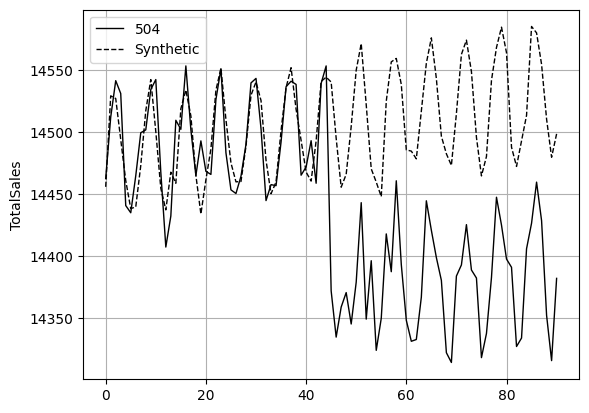

In [ ]:
# This gives us the actual sales of treatment vs synthetic control pre- and post-treatment
scm.path_plot(time_period=range(91))
# We can visually see that
# 1) the sales closely match in the pre-treatment period
# 2) in the post-treatment period, there's a drop in the treated group (the causal impact of stopping ads) compared to the synthetic control

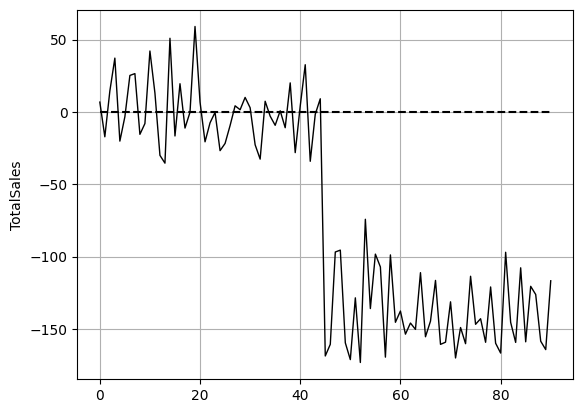

In [ ]:
# Here's another visualization that shows us the gap in total sales between the synthetic control and treated unit pre- and post-treatment
scm.gaps_plot(time_period=range(91))

# As we can see, pre-treatment, the difference is close to zero.
# But after treatment, the treated unit becomes about $140 lower than synthetic control

In [ ]:
# If we want to know the average treatment effect (i.e., the average daily drop in sales in the post-treatment period)
scm.att(time_period=range(45,91))
# the impact is $139.4, i.e., if we had kept our search ads in Philadelphia, our daily sales would've been $139.4 more per day in the post-treatment period

{'att': -139.0694728775268, 'se': 3.8034863051035006}

In [ ]:
# Finally, out of curiosity, if you want to know what thes synthetic control for Philadelphia looks like:
# The follwoing command gives us the weight assigned to each DMA (to create Synthetic Philadelphia) with DMAs with weight < 0.05 dropped
scm.weights(threshold=0.05)

# As we can see, the DMAs with largest weights are
# New York: 0.16
# Chicago: 0.25
# Boston-Manchester: 0.17
# Cleveland: 0.13
# FT-Myers-Naples: 0.08
# Honolulu: 0.19

501    0.134
602    0.336
506    0.159
510    0.050
571    0.109
744    0.193
Name: weights, dtype: float64

# Question 7: Conclusion
In a few well-developed paragraphs, summarize your key findings from eBay’s paid search advertising experiment. What did your analysis reveal about the incremental impact of paid search on total sales? Was the return on investment (ROI) higher or lower than eBay might have expected?

Be sure to discuss any important caveats to your conclusion. For instance, consider potential biases, data limitations, assumptions behind each method, as well as potential implications in a business setting. Are the any important missing components not reflected in the analysis?

Finally, based on your findings, what would you recommend as the next steps for eBay's marketing and analytics teams? Should they cut back on paid search? Invest more selectively?

What kind of follow-up analysis or testing would you propose before making major budget decisions?

eBay's paid search advertising experiment revealed that while the naive ROI calculation suggested a positive return of approximately 272%, a more rigorous causal analysis using difference-in-differences (DiD) showed a negative ROI of around -60%. This stark contrast highlights the risks of relying on attribution-based measures, which can significantly overstate the effectiveness of advertising by not accounting for the fact that many sales attributed to paid search may have occurred through organic channels anyway. The naive method used only pre-treatment data and attributed all sales during that period to paid search, without considering the counterfactual scenario where those sales might have happened regardless of the ads. In other words, it assumes AdSpend and TotalSales are perfectly correlated, which is not the case in reality.

The incremental impact of paid search on total sales was estimated to be around 17.54, but this estimate was only statistically significant after controlling for DMA fixed effects, which suggests that regional differences in sales levels were a major source of noise in the analysis. On the other hand, the cost of advertising was estimated to be around ~44 per day for the treatment DMAs during the post-treatment period, had the ads not been suspended. This return is lower than eBay might have expected based on the naive ROI, and based on this, eBay should consider cutting back on paid search or investing more selectively, while also conducting further analysis to confirm these findings before making major budget decisions.

Some caveats to these conclusions include potential biases from unobserved confounders that may not be fully accounted for even with fixed effects, as well as data limitations such as the granularity of sales and ad spend data. Additionally, the analysis assumes that the parallel trends assumption holds for the DiD estimation, which may not be perfectly valid. Implications in a business setting include the need for more careful attribution and measurement of advertising effectiveness, as well as the importance of using causal inference methods rather than relying on naive attribution. You are never 100% sure about the true ROI, but using rigorous methods can help you get closer to the truth and avoid costly mistakes.

Based on these findings, the next steps for eBay's marketing and analytics teams should include a more granular examination of the data to identify if there are specific segments or DMAs where paid search may still be effective. They should also consider running additional experiments, such as A/B tests with more targeted ad spend, to validate the findings from this analysis. Before making major budget decisions, it would be prudent to conduct a more detailed analysis of customer behavior, including how many sales attributed to paid search would have occurred through organic channels, and to explore alternative advertising strategies that may yield a better ROI.

Specifially, the kind of follow-up analyses I would propose include:
1. Segment-level analysis to identify if certain customer segments or product categories respond better to paid search
2. A/B testing with more targeted ad spend to validate the findings from this analysis
3. A more detailed analysis of customer behavior to understand the overlap between paid search and organic sales
4. Exploring alternative advertising strategies that may yield a better ROI, such as social media advertising or influencer partnerships.

# Parallel Trends Check

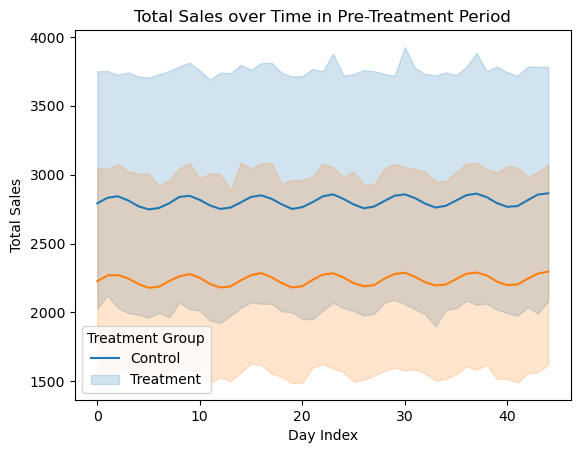

In [19]:
# We totally forgot to validate parallel trends.

#pandas show all columns
pd.set_option('display.max_columns', None)
# Lets do that now
# Only look at pre-treatment period
pre_treatment = df[df['Post'] == 0]
pre_treatment_t = pre_treatment[pre_treatment['Treatment'] == 1]
pre_treatment_c = pre_treatment[pre_treatment['Treatment'] == 0]

# The most intuitive way is to visualize the trends over time. We're looking for moving in tsame direction and at same slope.
import matplotlib.pyplot as plt
import seaborn as sns
sns.lineplot(data=pre_treatment, x='DayIndex', y='TotalSales', hue='Treatment')
plt.title('Total Sales over Time in Pre-Treatment Period')
plt.xlabel('Day Index')
plt.ylabel('Total Sales')
plt.legend(title='Treatment Group', labels=['Control', 'Treatment'])
plt.show()


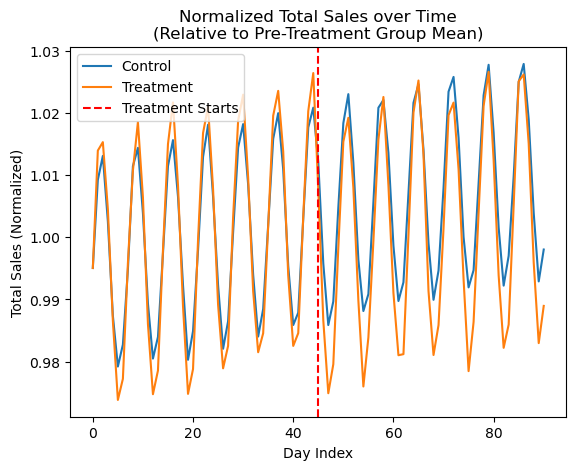

In [ ]:
# Normalize each group's daily average sales to its pre-treatment mean
pre_means = df[df['Post'] == 0].groupby('Treatment')['TotalSales'].mean()
df['TotalSales_norm'] = df.apply(lambda r: r['TotalSales'] / pre_means[r['Treatment']], axis=1)

daily_norm = df.groupby(['DayIndex', 'Treatment'])['TotalSales_norm'].mean().reset_index()
daily_norm['Treatment'] = daily_norm['Treatment'].map({0: 'Control', 1: 'Treatment'})

sns.lineplot(data=daily_norm, x='DayIndex', y='TotalSales_norm', hue='Treatment')
plt.title('Normalized Total Sales over Time\n(Relative to Pre-Treatment Group Mean)')
plt.axvline(x=45, color='red', linestyle='--', label='Treatment Starts')
plt.xlabel('Day Index')
plt.ylabel('Total Sales (Normalized)')
plt.legend()
plt.show()
# So it looks like parallel trends exist. In fact, the control continues on this trend during the treatment period while treatment drops off.

In [22]:
pre = df[df['Post'] == 0].copy()

# Test if Treatment group has a different time trend pre-treatment
model_pretrend = smf.ols(
    formula='TotalSales ~ Treatment * DayIndex + C(DMA)',
    data=pre
).fit()

coef = model_pretrend.params['Treatment:DayIndex']
pval = model_pretrend.pvalues['Treatment:DayIndex']
ci   = model_pretrend.conf_int().loc['Treatment:DayIndex']

print(f"Treatment x DayIndex coefficient: {coef:.4f}") 
# The treatment:DayIndex coefficient captures whether the treatment group had a different time trend than the control group in the pre-treatment period.
# We wnat it to be insignificant to make parallek trends true.
print(f"P-value: {pval:.4f}")
print(f"95% CI: [{ci[0]:.4f}, {ci[1]:.4f}]")
# Null hypothesis: parallel trends → coefficient should be ~0 and p > 0.05


Treatment x DayIndex coefficient: -0.0550
P-value: 0.4504
95% CI: [-0.1976, 0.0877]
